# Day 14 – CatBoost & Handling Categorical Features in Boosting

In this project, we explore CatBoost, a modern gradient boosting algorithm designed to handle categorical features efficiently.

We train a CatBoost regression model on the California Housing dataset and analyze model performance using feature importance, prediction plots, learning curves, and residual diagnostics.

We also compare CatBoost performance with XGBoost and LightGBM.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from catboost import CatBoostRegressor
import xgboost as xgb
import lightgbm as lgb

## Dataset

We use the California Housing dataset available in scikit-learn.

The dataset contains housing information such as:

- Median income
- House age
- Average rooms
- Population
- Latitude and longitude

The goal is to predict the median house value for districts in California.

In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

## Training the CatBoost Model

CatBoost is a gradient boosting algorithm that introduces two important innovations:

1. Ordered Boosting to prevent target leakage
2. Symmetric (oblivious) decision trees for faster inference and improved regularization

We train the model using early stopping based on validation error.

In [4]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

0:	learn: 1.1257668	test: 1.1117460	best: 1.1117460 (0)	total: 196ms	remaining: 1m 38s
100:	learn: 0.5371944	test: 0.5683805	best: 0.5683805 (100)	total: 711ms	remaining: 2.81s
200:	learn: 0.4889576	test: 0.5291100	best: 0.5291100 (200)	total: 1.1s	remaining: 1.63s
300:	learn: 0.4553207	test: 0.5025633	best: 0.5025633 (300)	total: 1.5s	remaining: 995ms
400:	learn: 0.4322651	test: 0.4883348	best: 0.4883348 (400)	total: 1.9s	remaining: 468ms
499:	learn: 0.4139715	test: 0.4793099	best: 0.4793066 (495)	total: 2.28s	remaining: 0us

bestTest = 0.4793065889
bestIteration = 495

Shrink model to first 496 iterations.


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [5]:
preds = cat_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.4517014673362548
R2: 0.8456987010619097


In [6]:
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05)
xgb_model.fit(X_train, y_train)

lgb_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05)
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 14448, number of used features: 8
[LightGBM] [Info] Start training from score 2.069240


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
xgb_preds = xgb_model.predict(X_test)
lgb_preds = lgb_model.predict(X_test)

print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))
print("LightGBM RMSE:", np.sqrt(mean_squared_error(y_test, lgb_preds)))

XGBoost RMSE: 0.44644816842414653
LightGBM RMSE: 0.42624824143067513


## Feature Importance

Feature importance shows which variables contribute the most to model predictions.

Understanding feature importance helps interpret the model and identify the most influential variables.

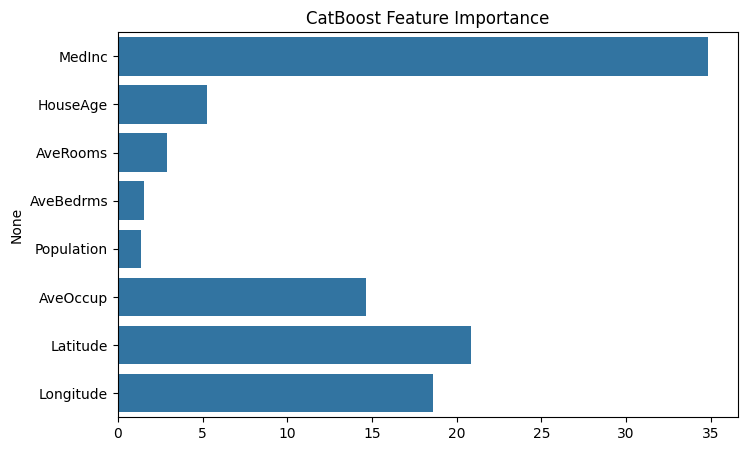

In [7]:
importances = cat_model.get_feature_importance()

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=X.columns)
plt.title("CatBoost Feature Importance")
plt.show()

## Prediction vs Actual Analysis

This scatter plot compares the predicted house prices with the actual prices.

If the model performs well, points should lie close to the diagonal line.

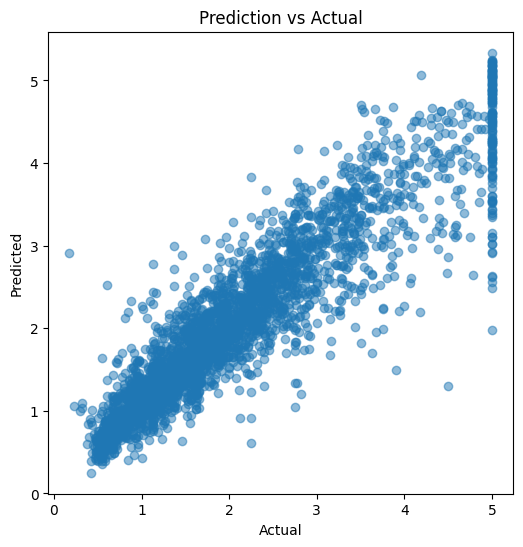

In [8]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, preds, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Prediction vs Actual")

plt.show()

## Learning Curves

Learning curves show how training and validation errors evolve during boosting iterations.

These curves help detect overfitting or underfitting.

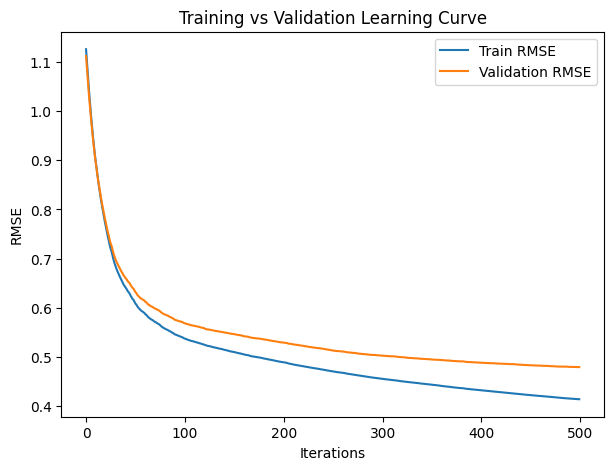

In [11]:
results = cat_model.get_evals_result()

train_rmse = results['learn']['RMSE']
val_rmse = results['validation']['RMSE']

plt.figure(figsize=(7,5))

plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Validation RMSE")

plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.title("Training vs Validation Learning Curve")

plt.legend()
plt.show()

## Residual Analysis

Residuals represent the difference between actual and predicted values.

A well-performing model should produce residuals that are approximately centered around zero with no strong patterns.

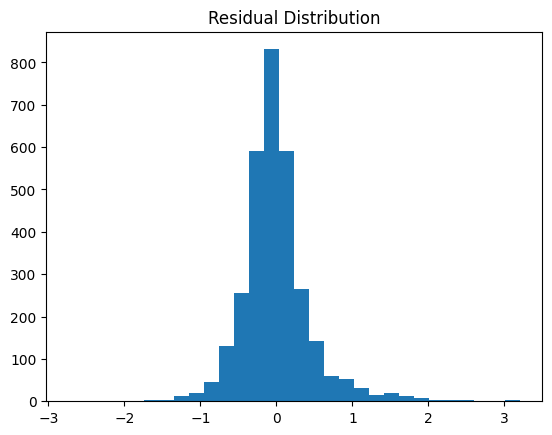

In [10]:
residuals = y_test - preds

plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()